# NaN Traffic Signals Verification

This notebook helps verify the 4511 traffic signals with NaN values in the `traffic_signals` field from OpenStreetMap data.

**Purpose**: Cross-check these locations with Google Earth to understand what these NaN values represent and whether they are relevant for noise prediction.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import os

## Load Traffic Signals Data

In [2]:
# Download traffic signals from OpenStreetMap
signals = ox.features_from_place("Barcelona, Spain", tags={"highway": "traffic_signals"})
signals = signals[signals.geometry.type == 'Point']

print(f"Total signals: {len(signals)}")
print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
print("\nValue counts:")
print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 6198
Non-null traffic_signals: 1687
Null traffic_signals: 4511

Value counts:
traffic_signals
NaN                    4511
signal                 1463
pedestrian_crossing     149
blinker                  42
traffic_lights           25
crossing                  8
Name: count, dtype: int64


## Filter and Prepare NaN Signals

In [3]:
# Filter signals with NaN traffic_signals values
nan_signals = signals[signals['traffic_signals'].isna()].copy()

# Convert to WGS84 (EPSG:4326) for Google Earth compatibility
nan_signals_wgs84 = nan_signals.to_crs(epsg=4326)

# Add latitude and longitude columns for easy reference
nan_signals_wgs84['longitude'] = nan_signals_wgs84.geometry.x
nan_signals_wgs84['latitude'] = nan_signals_wgs84.geometry.y

# Create a unique ID for each signal
nan_signals_wgs84['signal_id'] = range(1, len(nan_signals_wgs84) + 1)

print(f"Total NaN traffic signals: {len(nan_signals_wgs84)}")
print(f"\nFirst few locations:")
nan_signals_wgs84[['signal_id', 'latitude', 'longitude']].head(10)

Total NaN traffic signals: 4511

First few locations:


signal_id   latitude  longitude
element id                                       
node    26057049          1  41.374583   2.149220
        26057075          2  41.373377   2.175809
        30237627          3  41.388199   2.143772
        30237628          4  41.389042   2.144876
        30237633          5  41.392480   2.149415
        30237862          6  41.390718   2.151926
        30237866          7  41.390113   2.152933
        30237873          8  41.389089   2.154015
        30238006          9  41.387319   2.156231
        30238025         10  41.391618   2.157365

## Export to KML (Google Earth Format)

In [4]:
# Create output directory
output_dir = "../data/verification"
os.makedirs(output_dir, exist_ok=True)

# Save as KML (Google Earth format)
kml_path = os.path.join(output_dir, "nan_traffic_signals.kml")

# Remove existing file to prevent hanging
if os.path.exists(kml_path):
    os.remove(kml_path)
    print(f"Removed existing file: {kml_path}")

nan_signals_wgs84[['signal_id', 'geometry']].to_file(kml_path, driver='KML')

print(f"✓ Exported {len(nan_signals_wgs84)} NaN signals to KML: {kml_path}")
print(f"\nGoogle Earth Verification Process:")
print(f"1. Open Google Earth Pro or Google Earth Web")
print(f"2. File > Open > Select '{kml_path}'")
print(f"3. All NaN traffic signal locations will appear as placemarks")

Removed existing file: ../data/verification\nan_traffic_signals.kml
✓ Exported 4511 NaN signals to KML: ../data/verification\nan_traffic_signals.kml

Google Earth Verification Process:
1. Open Google Earth Pro or Google Earth Web
2. File > Open > Select '../data/verification\nan_traffic_signals.kml'
3. All NaN traffic signal locations will appear as placemarks


## Export Checklist CSV with Direct Google Earth Links

In [5]:
# Export to CSV for systematic checking
csv_path = os.path.join(output_dir, "nan_traffic_signals_checklist.csv")

# Create a checklist with relevant columns
checklist = nan_signals_wgs84[['signal_id', 'latitude', 'longitude']].copy()
checklist['google_earth_url'] = checklist.apply(
    lambda row: f"https://earth.google.com/web/@{row['latitude']},{row['longitude']},100a,500d,35y,0h,0t,0r", 
    axis=1
)
checklist['verified'] = ''
checklist['actual_type'] = ''
checklist['notes'] = ''

checklist.to_csv(csv_path, index=False)
print(f"✓ Exported checklist CSV: {csv_path}")
print(f"\nThe CSV contains:")
print(f"  - signal_id: Unique identifier")
print(f"  - latitude/longitude: Coordinates")
print(f"  - google_earth_url: Direct link to location")
print(f"  - verified: (Fill in: Yes/No)")
print(f"  - actual_type: (What you observe)")
print(f"  - notes: (Any observations)")
print(f"\nFirst 5 rows:")
checklist.head()

✓ Exported checklist CSV: ../data/verification\nan_traffic_signals_checklist.csv

The CSV contains:
  - signal_id: Unique identifier
  - latitude/longitude: Coordinates
  - google_earth_url: Direct link to location
  - verified: (Fill in: Yes/No)
  - actual_type: (What you observe)
  - notes: (Any observations)

First 5 rows:


signal_id   latitude  longitude  \
element id                                          
node    26057049          1  41.374583   2.149220   
        26057075          2  41.373377   2.175809   
        30237627          3  41.388199   2.143772   
        30237628          4  41.389042   2.144876   
        30237633          5  41.392480   2.149415   

                                                   google_earth_url verified  \
element id                                                                     
node    26057049  https://earth.google.com/web/@41.3745833,2.149...            
        26057075  https://earth.google.com/web/@41.373377,2.1758...            
        30237627  https://earth.google.com/web/@41.3881987,2.143...            
        30237628  https://earth.google.com/web/@41.3890419,2.144...            
        30237633  https://earth.google.com/web/@41.3924805,2.149...            

                 actual_type notes  
element id                          
node    26057049                    
        26057075                    
        30237627                    
        30237628                    
        30237633

## Create Random Sample for Initial Verification

A sample of 50 locations to identify patterns before checking all 4511.

In [7]:
# Create a random sample for initial verification (e.g., 50 locations)
sample_size = 50
sample_signals = nan_signals_wgs84.sample(n=min(sample_size, len(nan_signals_wgs84)), random_state=42)

sample_csv_path = os.path.join(output_dir, f"nan_traffic_signals_sample_{sample_size}.csv")
sample_checklist = sample_signals[['signal_id', 'latitude', 'longitude']].copy()
sample_checklist['google_earth_url'] = sample_checklist.apply(
    lambda row: f"https://earth.google.com/web/@{row['latitude']},{row['longitude']},100a,500d,35y,0h,0t,0r", 
    axis=1
)
sample_checklist['verified'] = ''
sample_checklist['actual_type'] = ''
sample_checklist['notes'] = ''

sample_checklist.to_csv(sample_csv_path, index=False)

# Also create KML for the sample
sample_kml_path = os.path.join(output_dir, f"nan_traffic_signals_sample_{sample_size}.kml")
sample_signals[['signal_id', 'geometry']].to_file(sample_kml_path, driver='KML')

print(f"✓ Created sample of {sample_size} random NaN signals")
print(f"  - KML: {sample_kml_path}")
print(f"  - CSV: {sample_csv_path}")


✓ Created sample of 50 random NaN signals
  - KML: ../data/verification\nan_traffic_signals_sample_50.kml
  - CSV: ../data/verification\nan_traffic_signals_sample_50.csv


## Visualize NaN vs Non-NaN Signals

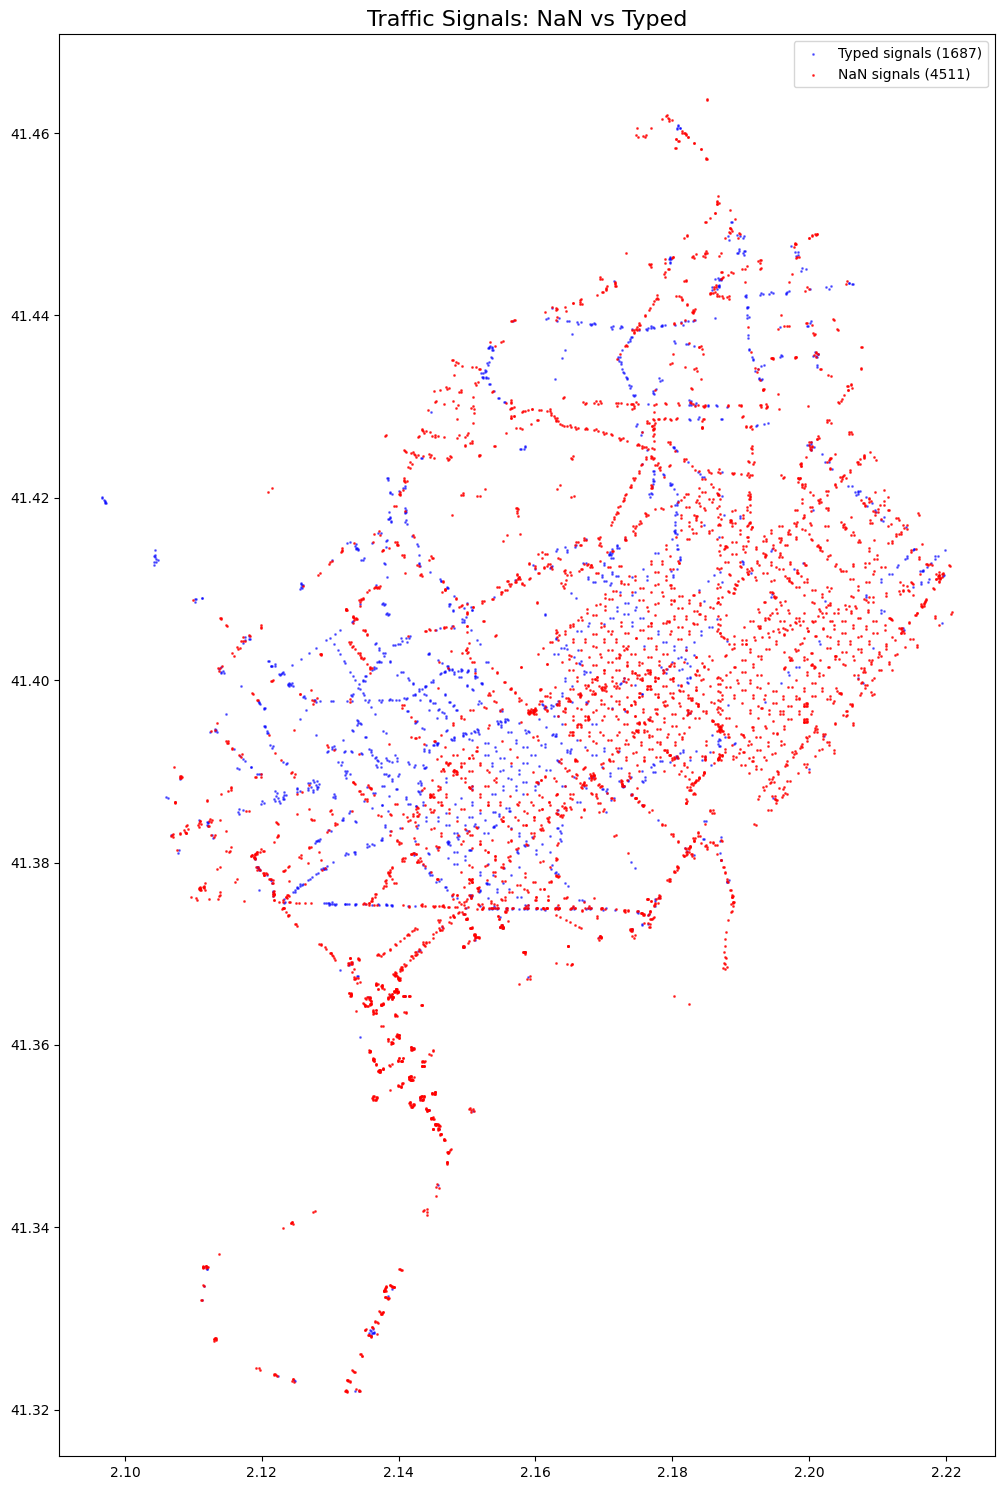

Red dots: NaN traffic signals (4511)
Blue dots: Typed traffic signals (1687)


In [ ]:
# Visualize NaN signals vs non-NaN signals on a map
fig, ax = plt.subplots(figsize=(15, 15))

# Plot all signals
signals_with_type = signals[signals['traffic_signals'].notna()]
nan_signals_plot = signals[signals['traffic_signals'].isna()]

# Plot non-NaN signals in blue
signals_with_type.plot(ax=ax, color='blue', markersize=1, alpha=0.5, label='Typed signals (1687)')

# Plot NaN signals in red
nan_signals_plot.plot(ax=ax, color='red', markersize=1, alpha=0.7, label='NaN signals (4511)')

ax.set_title("Traffic Signals: NaN vs Typed", fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Red dots: NaN traffic signals ({len(nan_signals_plot)})")
print(f"Blue dots: Typed traffic signals ({len(signals_with_type)})")

## Analysis: Spatial Distribution

Check if NaN signals are clustered in specific areas or distributed evenly across Barcelona.

In [9]:
# Calculate basic statistics on spatial distribution
print("Spatial Statistics:")
print(f"\nNaN Signals:")
print(f"  Latitude range: {nan_signals_wgs84['latitude'].min():.6f} to {nan_signals_wgs84['latitude'].max():.6f}")
print(f"  Longitude range: {nan_signals_wgs84['longitude'].min():.6f} to {nan_signals_wgs84['longitude'].max():.6f}")
print(f"  Mean latitude: {nan_signals_wgs84['latitude'].mean():.6f}")
print(f"  Mean longitude: {nan_signals_wgs84['longitude'].mean():.6f}")

signals_with_type_wgs84 = signals[signals['traffic_signals'].notna()].to_crs(epsg=4326)
signals_with_type_wgs84['latitude'] = signals_with_type_wgs84.geometry.y
signals_with_type_wgs84['longitude'] = signals_with_type_wgs84.geometry.x

print(f"\nTyped Signals:")
print(f"  Latitude range: {signals_with_type_wgs84['latitude'].min():.6f} to {signals_with_type_wgs84['latitude'].max():.6f}")
print(f"  Longitude range: {signals_with_type_wgs84['longitude'].min():.6f} to {signals_with_type_wgs84['longitude'].max():.6f}")
print(f"  Mean latitude: {signals_with_type_wgs84['latitude'].mean():.6f}")
print(f"  Mean longitude: {signals_with_type_wgs84['longitude'].mean():.6f}")

Spatial Statistics:

NaN Signals:
  Latitude range: 41.321986 to 41.463743
  Longitude range: 2.106769 to 2.220912
  Mean latitude: 41.396366
  Mean longitude: 2.167387

Typed Signals:
  Latitude range: 41.322040 to 41.460867
  Longitude range: 2.096631 to 2.219843
  Mean latitude: 41.401209
  Mean longitude: 2.156771


## Next Steps

1. **Start with the sample**: Open `nan_traffic_signals_sample_50.csv` and verify 50 random locations
2. **Look for patterns**: Are NaN signals mostly pedestrian crossings, traffic lights, or something else?
3. **Document findings**: Fill in the `actual_type` and `notes` columns
4. **Decide on approach**: Based on sample findings, determine if all 4511 need verification or if patterns are clear
5. **Update data model**: Adjust your noise prediction model based on what NaN signals represent